# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

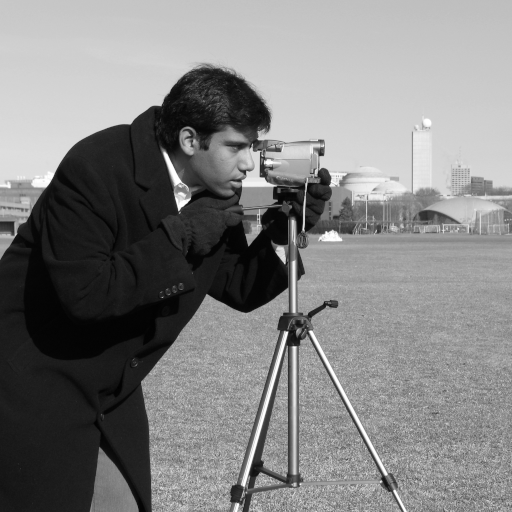

In [2]:
img = Image.fromarray(data.camera())

img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
width, height = img.size

cx = 2
cy = 2

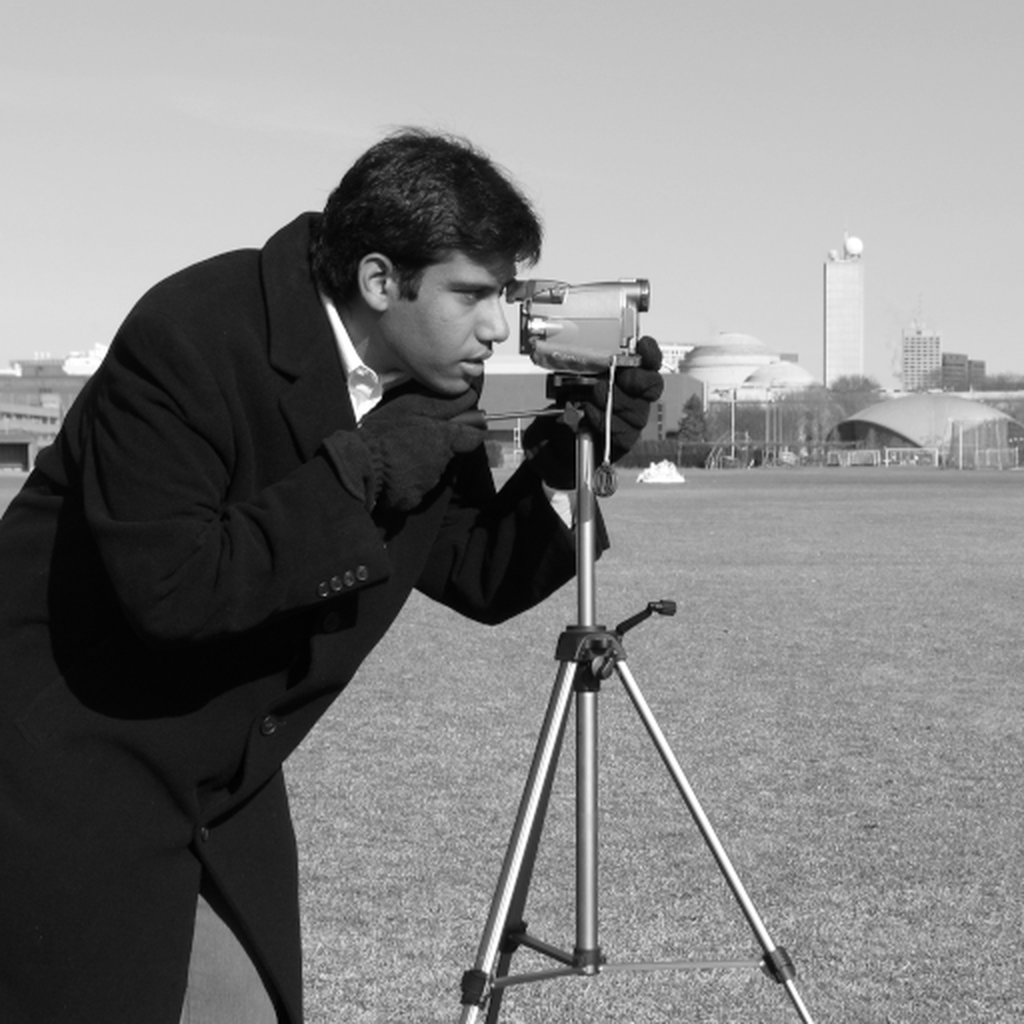

In [4]:
new_size = (int(width * cx), int(height * cy))

scaled_img = img.resize(new_size, Image.Resampling.LANCZOS)

scaled_img

In [5]:
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

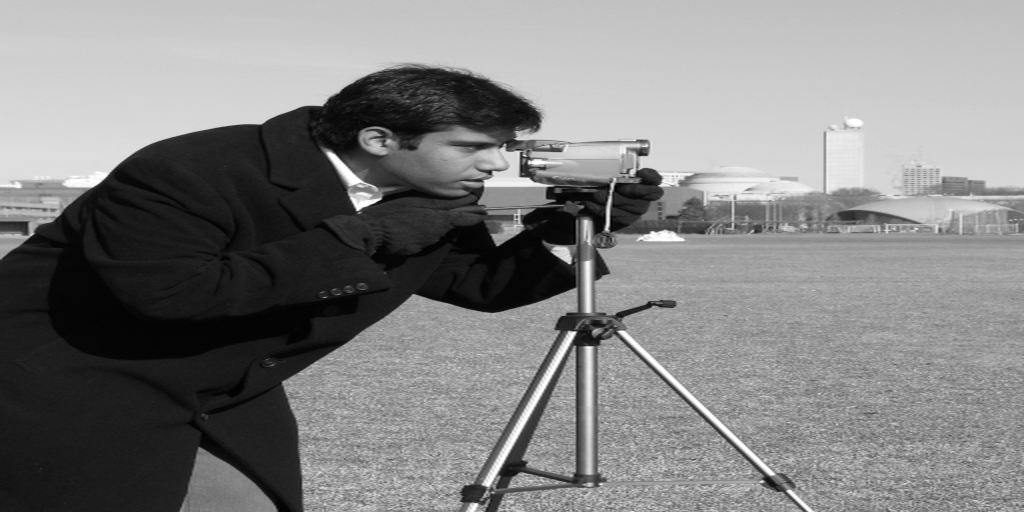

In [6]:
cx = 2
cy = 1

new_size = (int(width * cx), int(height * cy))

scaled_nonuniform = img.resize(new_size, Image.Resampling.LANCZOS)

scaled_nonuniform

In [7]:
scaled_nonuniform.save("task1_1_nonuniform.jpg")

In [8]:
print("Original size:", img.size)
print("Non-uniform scaled size:", scaled_nonuniform.size)

Original size: (512, 512)
Non-uniform scaled size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [ ]:
rotated_img = img.rotate(120, expand=True)

rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

rotated_img

### 3. Shear

In [ ]:
width, height = img.size

In [ ]:
shx = 0.5
shy = 0

shear_matrix = (1, shx, 0,
                shy, 1, 0)

In [ ]:
new_width = int(width + abs(shx) * height)

sheared_img = img.transform(
    (new_width, height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)

sheared_img

In [ ]:
sheared_img.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size:", sheared_img.size)

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [ ]:
img_array = np.array(img)

negative = 255 - img_array

negative_img = Image.fromarray(negative.astype(np.uint8))

negative_img

In [ ]:
img_array = np.array(img)

negative = 255 - img_array

negative_img = Image.fromarray(negative.astype(np.uint8))

negative_img

In [ ]:
c = 255 / np.log(1 + 255)

img_array = np.array(img.convert("L"))

log_transform = c * np.log(1 + img_array)

log_transform = np.clip(log_transform, 0, 255).astype(np.uint8)

log_img = Image.fromarray(log_transform)

log_img

/var/folders/js/fx438mmj7s760ztlqv3nm5v00000gp/T/ipykernel_52845/3479131171.py:13: RuntimeWarning: divide by zero encountered in log
  log_transformed_arr = c * np.log(1 + arr)
/var/folders/js/fx438mmj7s760ztlqv3nm5v00000gp/T/ipykernel_52845/3479131171.py:14: RuntimeWarning: invalid value encountered in cast
  log_transformed_arr = Image.fromarray(np.uint8(log_transformed_arr))


In [ ]:
gamma = 0.5

img_array = np.array(img.convert("L")) / 255.0

gamma_transform = 255 * (img_array ** gamma)

gamma_transform = np.clip(gamma_transform, 0, 255).astype(np.uint8)

gamma_img = Image.fromarray(gamma_transform)

gamma_img

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(negative_img, cmap="gray")
plt.title("Negative")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(log_img, cmap="gray")
plt.title("Log Transformation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gamma_img, cmap="gray")
plt.title("Gamma Correction")
plt.axis("off")

plt.tight_layout()
plt.show()